In [1]:
%pip install medmnist


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tqdm


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 9.4 MB/s eta 0:00:00a 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 9.9 MB/s eta 0:00:00ta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torch.utils.data as data
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


In [5]:
import medmnist
from medmnist import INFO

In [9]:
data_flag = 'tissuemnist'
download = True
root_disk = "./data"

NUM_EPOCHS = 5
BATCH_SIZE = 128
lr = 0.01

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [10]:
from torch.utils.data import random_split

# preprocessing
data_transform = transforms.Compose([
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download, size=224)
test_dataset = DataClass(split='test', transform=data_transform, download=download, size=224)
cal_dataset = DataClass(split='val',  transform=data_transform, download=download, size=224)

# split training set into train and validation
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader = data.DataLoader(dataset=val_subset, batch_size=2*BATCH_SIZE, shuffle=False)

100%|██████████| 3.43G/3.43G [06:20<00:00, 9.03MB/s] 


In [11]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset TissueMNIST of size 224 (tissuemnist_224)
    Number of datapoints: 165466
    Root location: /Users/nusretkizilaslan/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 1
    Meaning of labels: {'0': 'Collecting Duct, Connecting Tubule', '1': 'Distal Convoluted Tubule', '2': 'Glomerular endothelial cells', '3': 'Interstitial endothelial cells', '4': 'Leukocytes', '5': 'Podocytes', '6': 'Proximal Tubule Segments', '7': 'Thick Ascending Limb'}
    Number of samples: {'train': 165466, 'val': 23640, 'test': 47280}
    Description: We use the BBBC051, available from the Broad Bioimage Benchmark Collection. The dataset contains 236,386 human kidney cortex cells, segmented from 3 reference tissue specimens and organized into 8 categories. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. Each gray-scale image is 32×32×7 pixels, where 7 denotes 7 slices. We take maximum values across the slices and resize them into 28×28 gra

In [12]:
device = "cpu"

In [13]:
from torchvision import models

class DenseNetCustom(nn.Module):
    def __init__(self, num_classes=1000):
        super(DenseNetCustom, self).__init__()
        self.densenet = models.densenet121(pretrained=True)
        self.densenet.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.densenet(x)
        return x


model = DenseNetCustom(num_classes=n_classes)
model.to(device)
print(model)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/nusretkizilaslan/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:04<00:00, 8.03MB/s]


DenseNetCustom(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [12]:
%pip install mapie

Note: you may need to restart the kernel to use updated packages.


In [13]:
import copy
from sklearn.metrics import roc_auc_score

train_losses, val_losses = [], []
train_acc_list, val_acc_list = [], []
train_auc_list, val_auc_list = [], []
best_val_acc = 0.0
best_model_weights = None
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    train_probs, train_labels_all = [], []
    print(f"Started Epoch {epoch+1}")
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device).squeeze()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        train_probs.append(F.softmax(outputs, dim=1).detach().cpu().numpy())
        train_labels_all.append(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    train_probs = np.concatenate(train_probs)
    train_labels_all = np.concatenate(train_labels_all)
    train_auc = roc_auc_score(train_labels_all, train_probs, multi_class='ovr')
    train_auc_list.append(train_auc)

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct, total = 0, 0
    val_probs, val_labels_all = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).squeeze()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            val_probs.append(F.softmax(outputs, dim=1).cpu().numpy())
            val_labels_all.append(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_acc_list.append(val_acc)
    val_probs = np.concatenate(val_probs)
    val_labels_all = np.concatenate(val_labels_all)
    val_auc = roc_auc_score(val_labels_all, val_probs, multi_class='ovr')
    val_auc_list.append(val_auc)

    # Save best weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

    scheduler.step()
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Train AUC: {train_auc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val AUC: {val_auc:.4f}')

# Load best weights
model.load_state_dict(best_model_weights)
print(f'\nLoaded best model weights from Epoch {best_epoch} with Val Acc: {best_val_acc:.2f}%')

Started Epoch 1


100%|██████████| 1164/1164 [05:54<00:00,  3.29it/s]


Epoch [1/5] Train Loss: 0.9355 | Train Acc: 66.21% | Train AUC: 0.9195 | Val Loss: 1.0416 | Val Acc: 62.59% | Val AUC: 0.9196
Started Epoch 2


100%|██████████| 1164/1164 [05:53<00:00,  3.29it/s]


Epoch [2/5] Train Loss: 0.7590 | Train Acc: 72.77% | Train AUC: 0.9470 | Val Loss: 1.0996 | Val Acc: 62.12% | Val AUC: 0.9088
Started Epoch 3


100%|██████████| 1164/1164 [05:54<00:00,  3.28it/s]


Epoch [3/5] Train Loss: 0.7002 | Train Acc: 74.80% | Train AUC: 0.9549 | Val Loss: 0.8612 | Val Acc: 69.91% | Val AUC: 0.9372
Started Epoch 4


100%|██████████| 1164/1164 [05:54<00:00,  3.28it/s]


Epoch [4/5] Train Loss: 0.5362 | Train Acc: 81.04% | Train AUC: 0.9731 | Val Loss: 0.6794 | Val Acc: 76.56% | Val AUC: 0.9587
Started Epoch 5


100%|██████████| 1164/1164 [05:55<00:00,  3.27it/s]


Epoch [5/5] Train Loss: 0.4811 | Train Acc: 83.04% | Train AUC: 0.9782 | Val Loss: 0.6814 | Val Acc: 76.33% | Val AUC: 0.9587

Loaded best model weights from Epoch 4 with Val Acc: 76.56%


In [14]:
import os

save_path = f"densenet_tissuemnist_new_epoch{best_epoch}.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to densenet_tissuemnist_new_epoch4.pth


In [16]:
model = DenseNetCustom(num_classes=n_classes)
model = model.to(device)
model.load_state_dict(torch.load('./densenet_tissuemnist_epoch4.pth', map_location=device))
model.eval()

DenseNetCustom(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

In [16]:
print(len(test_loader))

185


In [ ]:
model.eval()
correct, total = 0, 0
all_probs, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device).squeeze()
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

test_acc = 100. * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Total samples: {total}")

np.savez('test_predictions.npz',
         probs=all_probs,
         labels=all_labels,
         test_acc=test_acc)
print(f"Saved to test_predictions.npz — probs: {all_probs.shape}, labels: {all_labels.shape}")


Testing: 100%|██████████| 185/185 [01:13<00:00,  2.52it/s]

Test Accuracy: 76.15%
Total samples: 47280
Saved to test_predictions.npz — probs: (47280, 8), labels: (47280,)


In [21]:
model.eval()
val_correct, val_total = 0, 0
val_probs, val_labels = [], []

cal_loader = data.DataLoader(dataset=cal_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
with torch.no_grad():
    for inputs, labels in tqdm(cal_loader, desc="Validation"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        val_total += labels.size(0)
        val_correct += predicted.eq(labels).sum().item()
        val_probs.append(probs.cpu().numpy())
        val_labels.append(labels.cpu().numpy())

val_probs = np.concatenate(val_probs)
val_labels = np.concatenate(val_labels)

val_acc = 100. * val_correct / val_total
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Total samples: {val_total}")

np.savez('val_predictions.npz',
         probs=val_probs,
         labels=val_labels,
         val_acc=val_acc)
print(f"Saved to val_predictions.npz — probs: {val_probs.shape}, labels: {val_labels.shape}")


Validation: 100%|██████████| 93/93 [21:35<00:00, 13.93s/it]

Validation Accuracy: 5267.80%
Total samples: 23640
Saved to val_predictions.npz — probs: (23640, 8), labels: (23640, 1)


In [16]:
from sklearn.base import BaseEstimator, ClassifierMixin
from PIL import Image

class TorchSklearnWrapper(BaseEstimator, ClassifierMixin):
    """Wraps a PyTorch classifier to be compatible with MAPIE/sklearn."""
    def __init__(self, torch_model, device='cuda', transform=None, batch_size=256):
        self.torch_model = torch_model
        self.device = device
        self.transform = transform
        self.batch_size = batch_size
        self.classes_ = np.arange(n_classes) 


    def fit(self, X, y=None):
        return self

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

    def predict_proba(self, X):
        self.torch_model.eval()
        all_proba = []
        dataset = torch.utils.data.TensorDataset(torch.tensor(X))
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        with torch.no_grad():
            for (batch,) in loader:
                if self.transform is not None:
                    imgs = []
                    for img in batch.numpy():
                        img = Image.fromarray(img.astype(np.uint8))
                        imgs.append(self.transform(img))
                    batch = torch.stack(imgs)
                else:
                    batch = batch.float()
                batch = batch.to(self.device)
                logits = self.torch_model(batch)
                proba = F.softmax(logits, dim=1)
                all_proba.append(proba.cpu().numpy())
        return np.vstack(all_proba)

wrapped_model = TorchSklearnWrapper(model, device=device, transform=data_transform)

wrapped_model.fit(cal_dataset.imgs, cal_dataset.labels.ravel())

,torch_model,DenseNetCusto...as=True) ) )
,device,'cuda'
,transform,"Compose( ..., std=[0.5]) )"
,batch_size,256


In [22]:
# Conformal prediction
from mapie.classification import SplitConformalClassifier


confidence_level = 0.90
mapie_classifier = SplitConformalClassifier(
    estimator=wrapped_model, confidence_level=confidence_level, prefit=True
)
mapie_classifier.conformalize(cal_dataset.imgs, cal_dataset.labels)
y_pred, y_pred_set = mapie_classifier.predict_set(test_dataset.imgs)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
import pandas as pd
import json

label_map = info['label']

records = []
for i in tqdm(range(len(y_pred)), desc="Conformal Prediction"):
    pred_label = int(y_pred[i])
    true_label = int(test_dataset.labels[i].item()) if hasattr(test_dataset.labels[i], 'item') else int(test_dataset.labels[i])
    # y_pred_set shape: (n_samples, n_classes) — boolean mask
    prediction_set = [int(c) for c in range(n_classes) if y_pred_set[i, c]]
    prediction_set_names = [label_map[str(c)] for c in prediction_set]
    records.append({
        'sample_index': i,
        'true_label': true_label,
        'true_label_name': label_map[str(true_label)],
        'predicted_label': pred_label,
        'predicted_label_name': label_map[str(pred_label)],
        'prediction_set': prediction_set,
        'prediction_set_names': prediction_set_names,
        'set_size': len(prediction_set),
        'true_label_in_set': true_label in prediction_set,
    })

df_conformal = pd.DataFrame(records)
df_conformal.to_csv('conformal_prediction_results.csv', index=False)
print(f"Saved conformal prediction results to conformal_prediction_results.csv")


# --- Save training metrics ---
df_training = pd.DataFrame({
    'epoch': list(range(1, len(train_losses) + 1)),
    # 'train_loss': train_losses,
    'train_accuracy': train_acc_list,
    # 'test_accuracy': test_acc_list,
})
df_training.to_csv('training_metrics.csv', index=False)

print(f"Saved training metrics to training_metrics.csv")


# --- Print summary statistics ---
coverage = df_conformal['true_label_in_set'].mean()
avg_set_size = df_conformal['set_size'].mean()
print(f"\nConformal Prediction Summary (confidence={confidence_level}):")
print(f"  Coverage (empirical): {coverage:.4f}")
print(f"  Average set size:     {avg_set_size:.4f}")
print(f"\nSet size distribution:")
print(df_conformal['set_size'].value_counts().sort_index().to_string())

Conformal Prediction: 100%|██████████| 47280/47280 [00:00<00:00, 91168.74it/s] 


Saved conformal prediction results to conformal_prediction_results.csv
Saved training metrics to training_metrics.csv

Conformal Prediction Summary (confidence=0.9):
  Coverage (empirical): 0.8986
  Average set size:     1.5323

Set size distribution:
set_size
1    27776
2    14535
3     4313
4      619
5       35
6        2


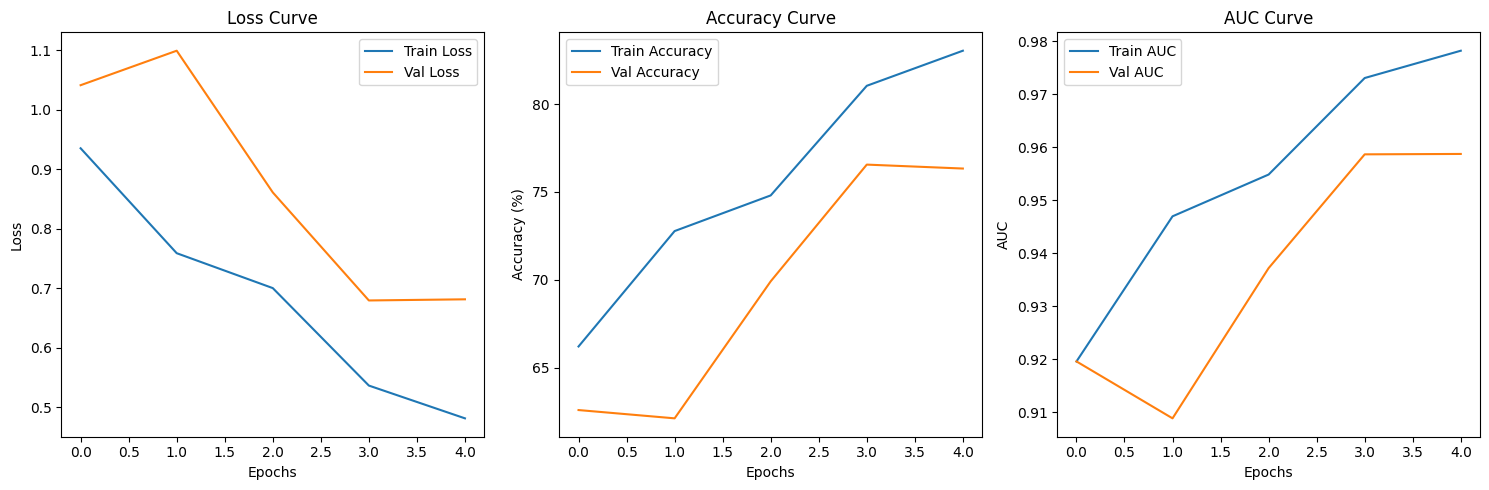

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_auc_list, label='Train AUC')
plt.plot(val_auc_list, label='Val AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('AUC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
coverage_per_class = df_conformal.groupby('true_label_name')['true_label_in_set'].mean()
print("Coverage per Class:")
print("-" * 40)
for cls, cov in coverage_per_class.items():
    n = (df_conformal['true_label_name'] == cls).sum()
    print(f"  {cls:30s} {cov:.4f}  (n={n})")
print("-" * 40)
print(f"  {'Overall':30s} {df_conformal['true_label_in_set'].mean():.4f}  (n={len(df_conformal)})")


Coverage per Class:
----------------------------------------
  Distal Convoluted Tubule       0.6323  (n=2233)
  Glomerular endothelial cells   0.8700  (n=1677)
  Interstitial endothelial cells 0.8914  (n=4402)
  Leukocytes                     0.8415  (n=3369)
  Podocytes                      0.8497  (n=2202)
  Proximal Tubule Segments       0.9396  (n=11201)
  Thick Ascending Limb           0.8902  (n=7031)
----------------------------------------
  Overall                        0.8986  (n=47280)
